# Business Understanding

## Project Domain

## Problem Statements

## Goals

## Solustion Statements

# Data Understanding

## Import Data dari Kaggle

In [10]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"teukualfathcyril","key":"eb529765bd071e61b8fc80965ccffa7e"}'}

In [11]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [15]:
!kaggle datasets download -d shubhankitsirvaiya06/diamond-price-prediction

Dataset URL: https://www.kaggle.com/datasets/shubhankitsirvaiya06/diamond-price-prediction
License(s): unknown


In [16]:
!mkdir diamond-price-prediction-dataset
!unzip diamond-price-prediction.zip -d diamond-price-prediction-dataset
!ls diamond-price-prediction-dataset

Archive:  diamond-price-prediction.zip
  inflating: diamond-price-prediction-dataset/diamonds.csv  
diamonds.csv


## Import Library yang dibutuhkan

In [88]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn import metrics
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix, classification_report
import pickle

## Exploratory Data Analysis

In [18]:
df = pd.read_csv('diamond-price-prediction-dataset/diamonds.csv')
print(df.head())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [20]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [22]:
df['carat'] = pd.to_datetime(df['carat'])

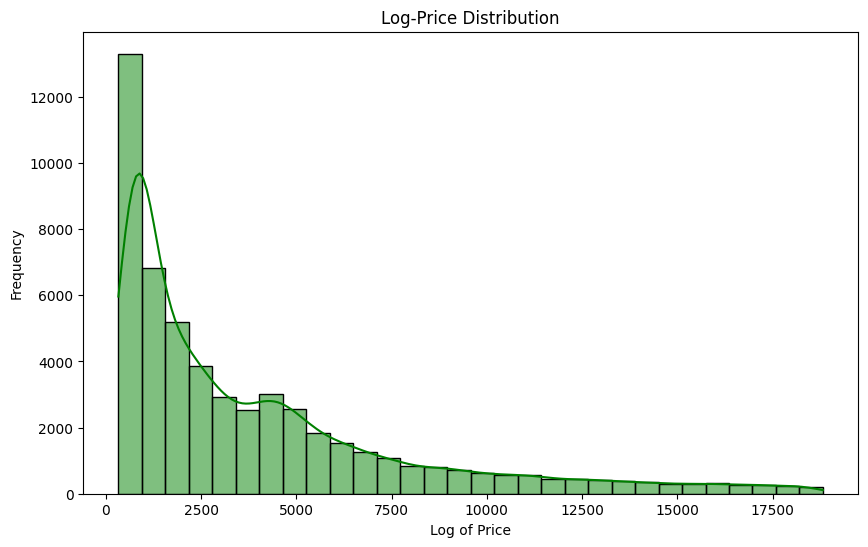

In [31]:
# Plot the histogram and KDE for log-transformed price
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=30, color='green')
plt.title('Log-Price Distribution')
plt.xlabel('Log of Price')
plt.ylabel('Frequency')
plt.show()

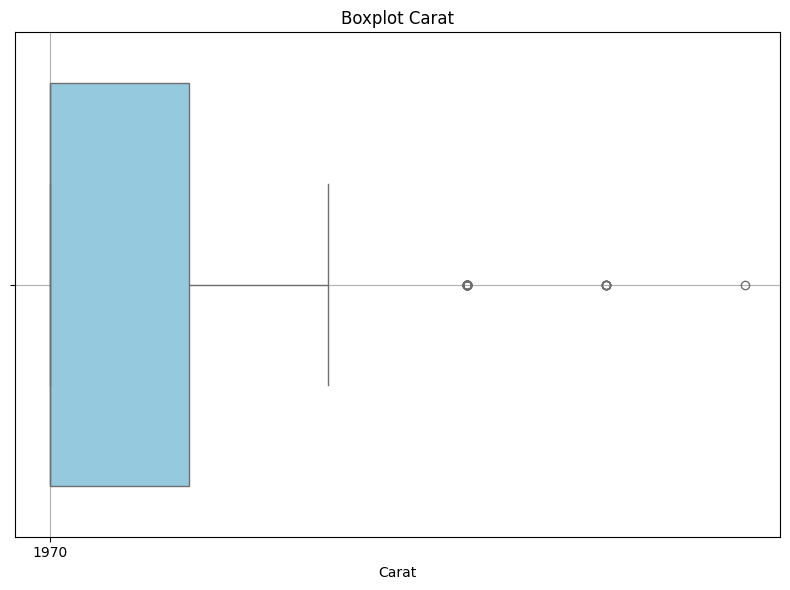

In [27]:
# Boxplot untuk carat
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['carat'], color='skyblue')
plt.title('Boxplot Carat')
plt.xlabel('Carat')
plt.grid(True)
plt.tight_layout()
plt.show()

<ipython-input-28-54d405380e45>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='clarity', data=df, order=df['clarity'].value_counts().index, palette='viridis')


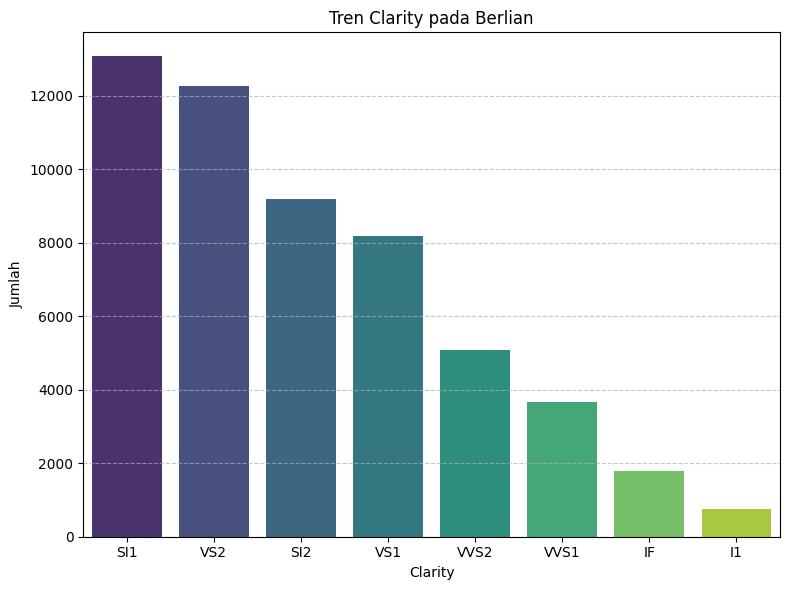

In [28]:
# tren untuk clarity
plt.figure(figsize=(8, 6))
sns.countplot(x='clarity', data=df, order=df['clarity'].value_counts().index, palette='viridis')
plt.title('Tren Clarity pada Berlian')
plt.xlabel('Clarity')
plt.ylabel('Jumlah')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

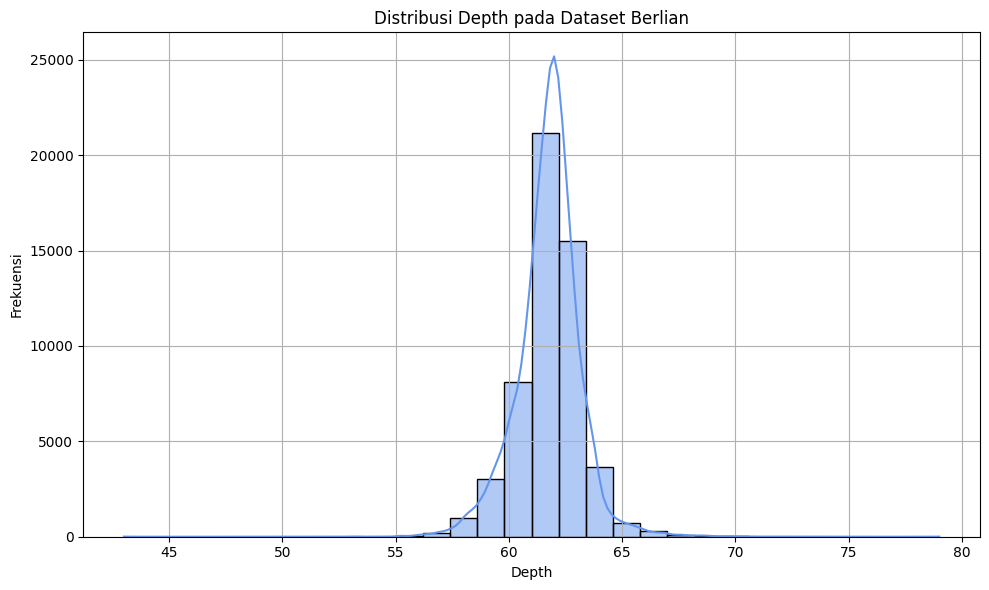

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df['depth'], bins=30, kde=True, color='cornflowerblue', edgecolor='black')
plt.title('Distribusi Depth pada Dataset Berlian')
plt.xlabel('Depth')
plt.ylabel('Frekuensi')
plt.grid(True)
plt.tight_layout()
plt.show()

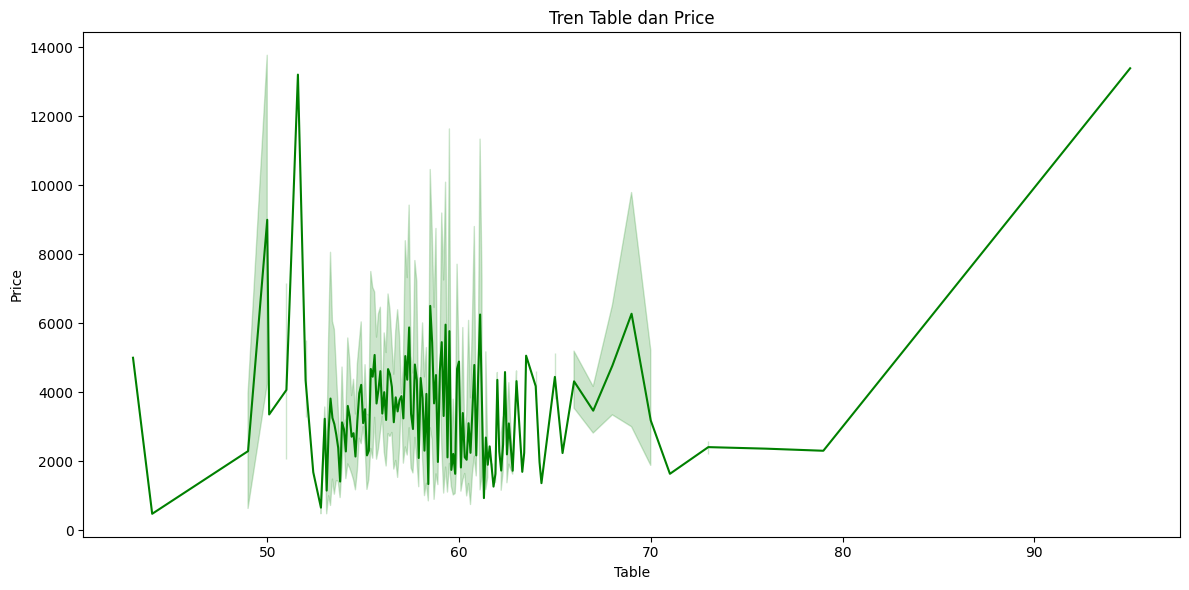

In [34]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='table', y='price', data=df, color='green')
plt.title('Tren Table dan Price')
plt.xlabel('Table')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

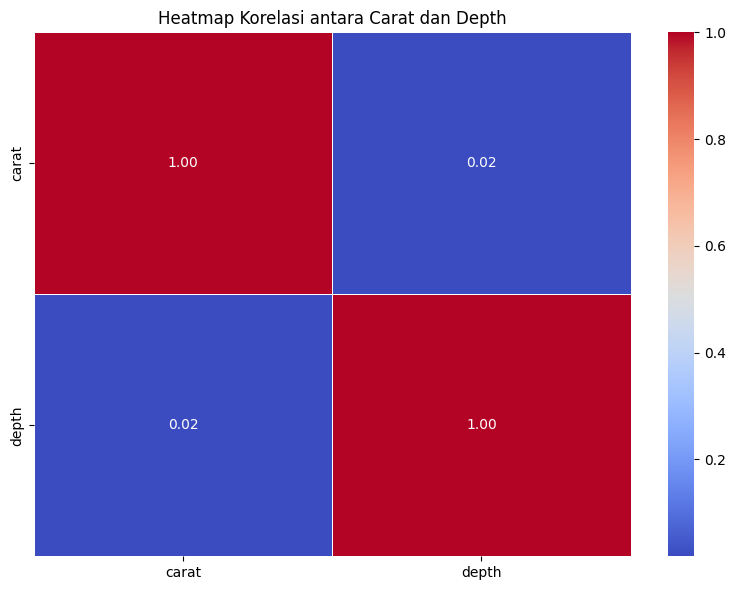

In [35]:
correlation_matrix = df[['carat', 'depth']].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi antara Carat dan Depth')
plt.tight_layout()
plt.show()

# Data Preparation

In [36]:
df = pd.read_csv('diamond-price-prediction-dataset/diamonds.csv')

In [38]:
missing_data = df.isnull().sum()

In [39]:
label_encoder = LabelEncoder()

df['cut'] = label_encoder.fit_transform(df['cut'])
df['color'] = label_encoder.fit_transform(df['color'])
df['clarity'] = label_encoder.fit_transform(df['clarity'])

In [44]:
df['carat'] = df['carat'].fillna(df['carat'].mean())
df['depth'] = df['depth'].fillna(df['depth'].mean())
df['table'] = df['table'].fillna(df['table'].mean())
df['price'] = df['price'].fillna(df['price'].mean())
df['x'] = df['x'].fillna(df['x'].mean())
df['y'] = df['y'].fillna(df['y'].mean())
df['z'] = df['z'].fillna(df['z'].mean())


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  int64  
 2   color    53940 non-null  int64  
 3   clarity  53940 non-null  int64  
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(4)
memory usage: 4.1 MB


In [42]:
X = df.drop('price', axis=1)  # Fitur (tanpa kolom price)
y = df['price']  # Target (kolom price)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Modeling

In [47]:
# Definisikan model
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))  # Input layer
model.add(Dense(32, activation='relu'))  # Hidden layer
model.add(Dense(1, activation='linear'))  # Output layer

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/50
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1103166.8750 - mae: 578.7451 - val_loss: 1002228.4375 - val_mae: 575.2742
Epoch 2/50
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1085885.1250 - mae: 575.6357 - val_loss: 996319.4375 - val_mae: 563.6584
Epoch 3/50
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1111080.7500 - mae: 581.0068 - val_loss: 996221.6875 - val_mae: 572.1606
Epoch 4/50
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1088228.6250 - mae: 578.3759 - val_loss: 994435.2500 - val_mae: 568.5983
Epoch 5/50
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1058799.3750 - mae: 570.3773 - val_loss: 1061752.5000 - val_mae: 625.5173
Epoch 6/50
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1074177.8750 - mae: 576.7791 - val_loss: 1011043.1250 - val_mae: 581.3225
Epoch 7/50
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1054280.5000 - mae: 570.4285 - val_loss: 981789.6250 - val_mae: 566.7211
Epoch 8/50
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/ste

# Evaluation

In [51]:
# Evaluasi model pada data uji
loss = model.evaluate(X_test, y_test)
print(f"Loss pada data uji: {loss}")

# Prediksi menggunakan model
y_pred = model.predict(X_test)

# Menghitung MSE atau MAE menggunakan sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")


338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1012595.0625
Loss pada data uji: 992992.75
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Mean Squared Error (MSE): 992992.5625
Mean Absolute Error (MAE): 561.50048828125


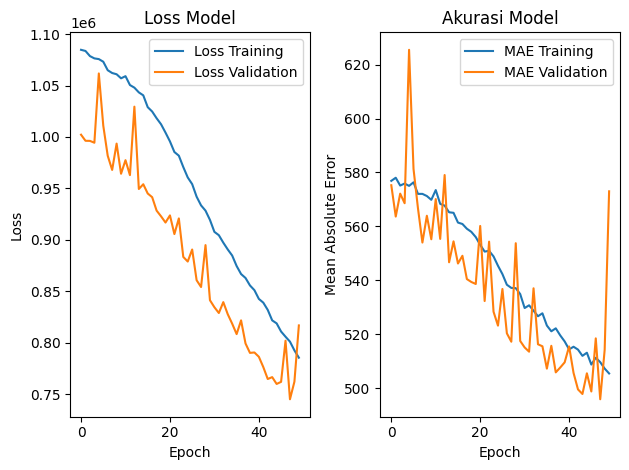

In [58]:


# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss Training')
plt.plot(history.history['val_loss'], label='Loss Validation')
plt.title('Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot akurasi (untuk model regresi, bisa menggunakan metric lain jika diperlukan)
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='MAE Training')
plt.plot(history.history['val_mae'], label='MAE Validation')
plt.title('Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()

plt.tight_layout()
plt.show()


338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


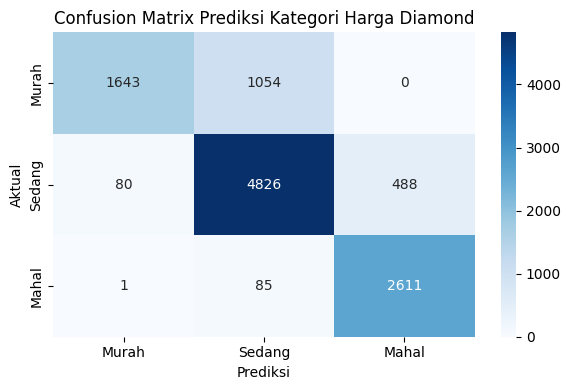

              precision    recall  f1-score   support

       Murah       0.84      0.97      0.90      2697
      Sedang       0.95      0.61      0.74      2697
       Mahal       0.81      0.89      0.85      5394

    accuracy                           0.84     10788
   macro avg       0.87      0.82      0.83     10788
weighted avg       0.85      0.84      0.84     10788



In [69]:
# Prediksi harga
y_pred = model.predict(X_test).flatten()

# Buat kategori harga aktual dan prediksi
bins = [0, np.percentile(y_test, 25), np.percentile(y_test, 75), np.max(y_test)]
labels = ['Murah', 'Sedang', 'Mahal']

# Ensure all predicted values fall within the defined bins
y_pred = np.clip(y_pred, bins[0], bins[-1])

y_actual_categories = pd.cut(y_test, bins=bins, labels=labels, include_lowest=True, duplicates='drop').astype(str)
y_predicted_categories = pd.cut(y_pred, bins=bins, labels=labels, include_lowest=True, duplicates='drop').astype(str)

# Matriks kebingungan
conf_matrix = confusion_matrix(y_actual_categories, y_predicted_categories, labels=labels)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Prediksi Kategori Harga Diamond")
plt.tight_layout()
plt.show()

# Classification Report
print(classification_report(y_actual_categories, y_predicted_categories, target_names=labels))

# MODEL SIMULATION


In [71]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


In [75]:
new_data = pd.DataFrame({
    'carat': [0.30],
    'cut': [1],         # asumsikan label encoding: 1 = Fair
    'color': [4],       # asumsikan 4 = I
    'clarity': [2],     # asumsikan 2 = VS2
    'depth': [62.0],
    'table': [57.0],
    'x': [4.2],
    'y': [4.3],
    'z': [2.6]
})

In [77]:
# Tentukan fitur numerik yang ingin di-scale (kecuali target dan kategori)
numerical_features = ['carat', 'depth', 'table', 'x', 'y', 'z']

# Buat DataFrame hanya dengan fitur numerik
new_data_numerical = new_data[numerical_features]

# Fit scaler pada data numerik (dalam praktik sebenarnya, ini dilakukan pada data latih)
scaler = StandardScaler()
scaler.fit(new_data_numerical)  # Biasanya fit ini pada data training, bukan pada 1 baris data baru

# Transformasi data numerik
new_data[numerical_features] = scaler.transform(new_data_numerical)

# Tampilkan hasil
print(new_data)

   carat  cut  color  clarity  depth  table    x    y    z
0    0.0    1      4        2    0.0    0.0  0.0  0.0  0.0


In [81]:
data = pd.DataFrame({
    'carat': [0.23, 0.21, 0.23, 0.29, 0.31],
    'cut': [2, 3, 1, 3, 1],       # encoded
    'color': [1, 1, 1, 5, 6],     # encoded
    'clarity': [3, 2, 4, 5, 3],   # encoded
    'depth': [61.5, 59.8, 56.9, 62.4, 63.3],
    'table': [55.0, 61.0, 65.0, 58.0, 58.0],
    'x': [3.95, 3.89, 4.05, 4.20, 4.34],
    'y': [3.98, 3.84, 4.07, 4.23, 4.35],
    'z': [2.43, 2.31, 2.31, 2.63, 2.75]
})

In [82]:
# Standarisasi data numerik
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [78]:
new_data_lstm = new_data.astype(np.float32).values.reshape(1, new_data.shape[1], 1)


In [83]:
# Konversi ke format LSTM: (samples=1, timesteps=5, features=10)
data_lstm = data_scaled.astype(np.float32).reshape(1, data.shape[0], data.shape[1])

In [84]:
print("LSTM input shape:", data_lstm.shape)

LSTM input shape: (1, 5, 9)


In [85]:
prediction = model.predict(new_data)
print("Prediksi harga berlian:", prediction[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
Prediksi harga berlian: [-3042.0872]


# Deployment

## Save Model

In [86]:
# Konversi ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.experimental_enable_resource_variables = True
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

# Simpan model TFLite
with open('diamond_price_prediction_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Model berhasil dikonversi dan disimpan sebagai 'diamond_price_prediction_model.tflite'")

Saved artifact at '/tmp/tmpgq071nbs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 9), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138205829674384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138205829675536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138205829675152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138205829675920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138205829676304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138205829676496: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Model berhasil dikonversi dan disimpan sebagai 'diamond_price_prediction_model.tflite'


In [89]:
with open('diamond_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Scaler berhasil disimpan sebagai 'diamond_scaler.pkl'")

✅ Scaler berhasil disimpan sebagai 'diamond_scaler.pkl'
